### Unsupervised Pipeline High-level Description

#### Phase 0: Data Integrity & Validation
Key Question - how does the data look? 

1. Combine CXR meta and chexpert files, filter on pneumonia (0,1) and jpeg image position (Chest PA and Lat)
2. Check for missing/null values, image paths, etc. 

#### Phase 1 - Preprocessing & KMeans Clustering Run (centroid based, spherical shapes)
Key Question - does K-means do a good job of clustering pneumonia vs. not? 

1. Using HuggingFace transform and pre-trained ResNet50: https://huggingface.co/Lab-Rasool/RadImageNet 
2. Extract embeddings from ResNet50 for each image to use for unsupervised task instead of using raw pixels
3. Standardize embeddings using StandardScaler and use PCA for dimensionality reduction fixed to 50 components to create a stable baseline. 
4. Use PCA space for downstream KMeans, DBSCAN and visualizations
5. Conduct a KMeans sweep across a range of predefined clusters from 2 to 10 and evaluate model for silhouette score, ARI and NMI. Goal to find high silhouette and high ARI/NMI.
6. Visualize using tSNE computed from PCA features and compare clusters with pneumonia classification.

#### Phase 2 - Preprocessing & DBSCAN Clustering Run (density based, complex shapes, noise/outlier discovery)
Key Question - are there complex clusters that DBSCAN can identify for pneumonia vs. not? 

1. PCA features same as above for KMeans
2. Optimize parameters: eps (using k-distance plot) and min-samples over a range (5, 10, 20)
3. Evalute how much was assigned noise/outliers and if they are not pneumonia.

#### Phase 3 - Pneumonia Phenotypes (if time permits)
1. Restrict Pneumonia flag = 1 and same steps as above: PCA, KMeans, DBSCAN, Evaluation, Visualization

### 00 - Imports, Dataset, Save Along the Way

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib
import matplotlib.pyplot as plt

In [2]:
ARTIFACTS_DIR = Path("artifacts")
RESULTS_DIR = Path("results")
FIG_DIR = Path("figures")

for d in [ARTIFACTS_DIR, RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMAGE_COL = "image_path"
LABEL_COL = "pneumonia"

In [3]:
chex_img_df = pd.read_csv('chex_img_merged.csv')

df = chex_img_df.copy()

df = df.dropna(subset=["image_path", "pneumonia"]).copy()
df["pneumonia"] = df["pneumonia"].astype(int)
df = df.drop_duplicates(subset=["image_path"]).reset_index(drop=True)

print("N:", len(df))
print(df["pneumonia"].value_counts())

N: 69580
0    43358
1    26222
Name: pneumonia, dtype: int64


### 01 - Extract Embeddings for PCA

In [4]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [5]:
class CXRDataset(Dataset):
    def __init__(self, df, image_col="image_path", label_col="pneumonia", transform=None):
        self.df = df.reset_index(drop=True)
        self.image_col = image_col
        self.label_col = label_col
        self.transform = transform or preprocess

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row[self.image_col]
        y = int(row[self.label_col])

        img = Image.open(path).convert("RGB")   # important
        x = self.transform(img)
        return x, y, idx

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
from torchvision import models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Remove classification head → output 2048-d embeddings
model.fc = nn.Identity()

model.eval().to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [8]:
#extract embeddings and save them
emb_path = ARTIFACTS_DIR / "embeddings.npy"
lab_path = ARTIFACTS_DIR / "labels.npy"
meta_path = ARTIFACTS_DIR / "meta.csv"

if emb_path.exists() and lab_path.exists() and meta_path.exists():
    X = np.load(emb_path)
    y = np.load(lab_path)
    meta = pd.read_csv(meta_path)
    print("Loaded cached embeddings:", X.shape)

else:
    ds = CXRDataset(df, image_col=IMAGE_COL, label_col=LABEL_COL, transform=preprocess)
    
    dl = DataLoader(
        ds,
        batch_size=64,
        shuffle=False,
        num_workers=4,
        pin_memory=(device.type == "cuda"),
    )

    N = len(ds)
    X = np.zeros((N, 2048), dtype=np.float32)
    y = np.zeros((N,), dtype=np.int64)

    model.eval()
    with torch.no_grad():
        for xb, yb, idx in tqdm(dl, total=len(dl)):
            xb = xb.to(device, non_blocking=True)
            feats = model(xb).detach().cpu().numpy().astype(np.float32)
            idx_np = idx.numpy()
            X[idx_np] = feats
            y[idx_np] = yb.numpy()

    meta = df.reset_index(drop=True).copy()
    meta.to_csv(meta_path, index=False)

    np.save(emb_path, X)
    np.save(lab_path, y)

    print("Saved:", emb_path, lab_path, meta_path)

Loaded cached embeddings: (69580, 2048)


### 02 - PCA Analysis

In [9]:
#review the embedding artifacts loaded from previous
X = np.load(ARTIFACTS_DIR / "embeddings.npy")
y = np.load(ARTIFACTS_DIR / "labels.npy")
meta = pd.read_csv(ARTIFACTS_DIR / "meta.csv")

X.shape, y.shape, meta.shape

((69580, 2048), (69580,), (69580, 4))

In [10]:
#standardize the embeddings
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_std)

joblib.dump({"scaler": scaler, "pca": pca}, ARTIFACTS_DIR / "pca.joblib")
np.save(ARTIFACTS_DIR / "X_pca.npy", X_pca)

evr = pca.explained_variance_ratio_
pd.DataFrame({
    "component": np.arange(1, len(evr)+1),
    "explained_variance_ratio": evr,
    "cumulative": np.cumsum(evr)
}).to_csv(RESULTS_DIR / "pca_variance.csv", index=False)

print("Saved PCA artifacts.")
print("Cumulative variance @50:", np.cumsum(evr)[-1])

Saved PCA artifacts.
Cumulative variance @50: 0.42345948607822


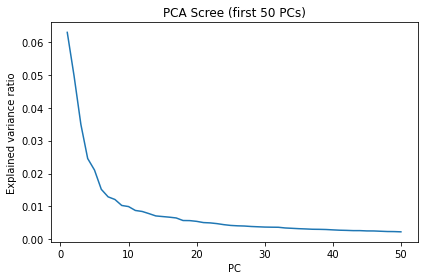

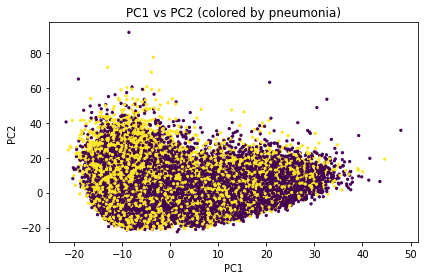

In [11]:
#visualize the PCA components 
# scree
plt.figure()
plt.plot(np.arange(1, len(evr)+1), evr)
plt.xlabel("PC")
plt.ylabel("Explained variance ratio")
plt.title("PCA Scree (first 50 PCs)")
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_scree.png", dpi=200)

# PC1 vs PC2
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 (colored by pneumonia)")
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_pc1_pc2.png", dpi=200)
plt.show()

In [12]:
pc_means = []
for j in range(5):
    pc_means.append({
        "pc": j+1,
        "mean_pneumonia0": X_pca[y==0, j].mean(),
        "mean_pneumonia1": X_pca[y==1, j].mean(),
        "diff": X_pca[y==1, j].mean() - X_pca[y==0, j].mean()
    })
pc_means_df = pd.DataFrame(pc_means)
pc_means_df

,pc,mean_pneumonia0,mean_pneumonia1,diff
0,1,0.867585,-1.434549,-2.302134
1,2,-0.711522,1.176499,1.888021
2,3,0.746677,-1.234628,-1.981305
3,4,0.069803,-0.115420,-0.185222
4,5,-0.723461,1.196241,1.919702


### 03 - KMeans Model Run

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
X_pca = np.load(ARTIFACTS_DIR / "X_pca.npy")      # (N, D)
y = np.load(ARTIFACTS_DIR / "labels.npy")         # (N,)

In [15]:
rng = np.random.default_rng(42)
sample_size = min(5000, len(y))
sample_idx = rng.choice(len(y), size=sample_size, replace=False)

y_s = y[sample_idx].astype(np.int32)

In [16]:
rows = []
k_range = range(2, 11)

for k in tqdm(k_range, desc="KMeans run"):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_pca).astype(np.int32)

    # Silhouette score on full dataset
    sil = silhouette_score(X_pca, labels)

    # ARI and NMI on sample to test a few
    labels_s = labels[sample_idx]
    ari = adjusted_rand_score(y_s, labels_s)
    nmi = normalized_mutual_info_score(y_s, labels_s)

    # Cluster diagnostics
    counts = np.bincount(labels)
    rows.append({
        "k": k,
        "silhouette": float(sil),
        "ari_sample": float(ari),
        "nmi_sample": float(nmi),
        "min_cluster": int(counts.min()),
        "max_cluster": int(counts.max()),
        "sample_size": int(sample_size),
    })

kmeans_run = pd.DataFrame(rows).sort_values("k")
kmeans_run.to_csv(RESULTS_DIR / "kmeans_run.csv", index=False)

display(kmeans_run)

KMeans run:   0%|          | 0/9 [00:00<?, ?it/s]

,k,silhouette,ari_sample,nmi_sample,min_cluster,max_cluster,sample_size
0,2,0.148164,-0.005684,0.006998,24383,45197,5000
1,3,0.124773,0.014992,0.010791,13955,31777,5000
2,4,0.070416,0.012896,0.010994,10695,23396,5000
3,5,0.077715,0.004498,0.011970,7660,21671,5000
4,6,0.055150,0.009835,0.013602,6199,16673,5000
5,7,0.052997,0.008938,0.013136,5979,16322,5000
6,8,0.049328,0.008748,0.012403,3812,15101,5000
7,9,0.050078,0.010631,0.015334,3438,14110,5000
8,10,0.049656,0.009648,0.015206,3366,14028,5000


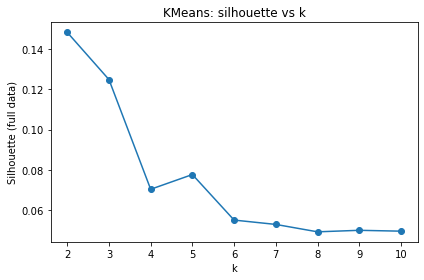

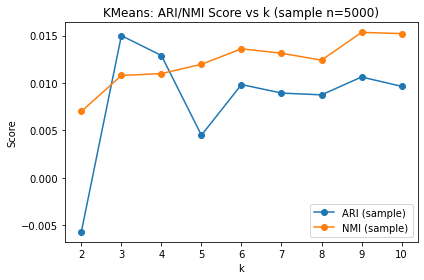

In [17]:
plt.figure()
plt.plot(kmeans_run["k"], kmeans_run["silhouette"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette (full data)")
plt.title("KMeans: silhouette vs k")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(kmeans_run["k"], kmeans_run["ari_sample"], marker="o", label="ARI (sample)")
plt.plot(kmeans_run["k"], kmeans_run["nmi_sample"], marker="o", label="NMI (sample)")
plt.xlabel("k")
plt.ylabel("Score")
plt.title(f"KMeans: ARI/NMI Score vs k (sample n={sample_size})")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
#pick the best k
# simple heuristic: maximize ARI, break ties with silhouette
best_row = kmeans_run.sort_values(["ari_sample", "silhouette"], ascending=False).iloc[0]
best_k = int(best_row["k"])
print("Best k:", best_k, best_row.to_dict())

km = KMeans(n_clusters=best_k, n_init=20, random_state=42)
kmeans_labels = km.fit_predict(X_pca)

np.save(ARTIFACTS_DIR / f"kmeans_labels_k{best_k}.npy", kmeans_labels)

Best k: 3 {'k': 3.0, 'silhouette': 0.12477309256792068, 'ari_sample': 0.01499232935783689, 'nmi_sample': 0.01079079328294794, 'min_cluster': 13955.0, 'max_cluster': 31777.0, 'sample_size': 5000.0}


In [19]:
best_k

3

### 04 - DBSCAN Run

In [20]:
#imports and use saved data
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_pca = np.load(ARTIFACTS_DIR / "X_pca.npy")
y = np.load(ARTIFACTS_DIR / "labels.npy")

In [21]:
#https://github.com/amueller/mglearn/blob/main/mglearn/plot_dbscan.py
#https://medium.com/@kaleemullahyounas123/dbscan-another-clustering-algorithm-for-machine-learning-89885f555a2e

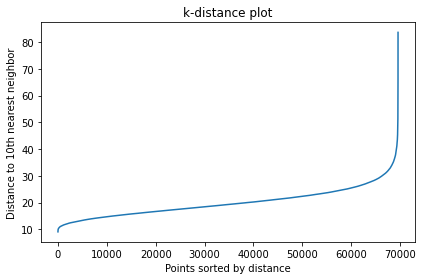

In [22]:
#choosing eps and min_samples
def k_distance_plot(X, k=10):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)
    # distance to kth neighbor
    kth = np.sort(distances[:, -1])
    plt.figure()
    plt.plot(kth)
    plt.xlabel("Points sorted by distance")
    plt.ylabel(f"Distance to {k}th nearest neighbor")
    plt.title("k-distance plot")
    plt.tight_layout()
    plt.show()
    return kth

_ = k_distance_plot(X_pca, k=10)

In [23]:
#guess the elbow/knee based on k-distance plot above
elbow_pt = 30

#define the parameter grid
eps_grid = np.linspace(10, elbow_pt, 10)
min_samples_grid = [5, 10, 20]

In [24]:
#run a sample for the ARI/NMI 
rng = np.random.default_rng(42)
sample_size = min(5000, len(y))
sample_idx = rng.choice(len(y), size=sample_size, replace=False)
y_s = y[sample_idx]

In [25]:
rows = []

for ms in tqdm(min_samples_grid, desc="DBSCAN min_samples"):
    for eps in tqdm(eps_grid, desc=f"eps grid (ms={ms})", leave=False):
        db = DBSCAN(eps=float(eps), min_samples=int(ms))
        labels = db.fit_predict(X_pca).astype(np.int32)

        non_noise = labels != -1
        noise_pct = float((~non_noise).mean())

        # number of clusters excluding noise
        n_clusters = int(len(set(labels[non_noise]))) if non_noise.any() else 0

        # ARI/NMI calculations
        labels_s = labels[sample_idx]
        ari = adjusted_rand_score(y_s, labels_s)
        nmi = normalized_mutual_info_score(y_s, labels_s)

        #Silhouette Calculations
        sil = np.nan
        if n_clusters >= 2 and non_noise.sum() > 50:
            try:
                sil = float(silhouette_score(X_pca[non_noise], labels[non_noise]))
            except Exception:
                sil = np.nan

        rows.append({
            "eps": float(eps),
            "min_samples": int(ms),
            "n_clusters": n_clusters,
            "noise_pct": noise_pct,
            "ari_sample": float(ari),
            "nmi_sample": float(nmi),
            "silhouette_non_noise": sil,
            "sample_size": int(sample_size),
        })

dbscan_sweep = pd.DataFrame(rows)
dbscan_sweep.to_csv(RESULTS_DIR / "dbscan_sweep.csv", index=False)

display(dbscan_sweep.sort_values(["ari_sample", "n_clusters", "silhouette_non_noise"], ascending=False).head(20))

DBSCAN min_samples:   0%|          | 0/3 [00:00<?, ?it/s]

eps grid (ms=5):   0%|          | 0/10 [00:00<?, ?it/s]

eps grid (ms=10):   0%|          | 0/10 [00:00<?, ?it/s]

eps grid (ms=20):   0%|          | 0/10 [00:00<?, ?it/s]

,eps,min_samples,n_clusters,noise_pct,ari_sample,nmi_sample,silhouette_non_noise,sample_size
6,23.333333,5,1,0.126832,0.009165,0.001273,NaN,5000
17,25.555556,10,1,0.074619,0.009150,0.001640,NaN,5000
7,25.555556,5,1,0.070652,0.008817,0.001607,NaN,5000
27,25.555556,20,1,0.078916,0.008689,0.001429,NaN,5000
16,23.333333,10,1,0.133659,0.008292,0.001038,NaN,5000
26,23.333333,20,1,0.142110,0.007881,0.000931,NaN,5000
5,21.111111,5,3,0.226847,0.004159,0.000315,0.146286,5000
28,27.777778,20,1,0.043533,0.003746,0.000469,NaN,5000
25,21.111111,20,2,0.252271,0.003302,0.000397,0.208234,5000
15,21.111111,10,1,0.239451,0.003249,0.000211,NaN,5000


In [26]:
#choose the best DBSCAN parameters from the grid earlier
best = dbscan_sweep.sort_values(["ari_sample", "n_clusters", "silhouette_non_noise"], ascending=False).iloc[0]
best_eps = float(best["eps"])
best_ms = int(best["min_samples"])
print("Best DBSCAN:", best.to_dict())

db = DBSCAN(eps=best_eps, min_samples=best_ms)
dbscan_labels = db.fit_predict(X_pca)

np.save(ARTIFACTS_DIR / "dbscan_labels_best.npy", dbscan_labels)

Best DBSCAN: {'eps': 23.333333333333336, 'min_samples': 5.0, 'n_clusters': 1.0, 'noise_pct': 0.1268324231100891, 'ari_sample': 0.009165001727586046, 'nmi_sample': 0.0012726491163974139, 'silhouette_non_noise': nan, 'sample_size': 5000.0}


### 05 - tSNE for visualization

In [27]:
from sklearn.manifold import TSNE

In [28]:
# KMeans: use whichever best_k you saved earlier
kmeans_labels = np.load(ARTIFACTS_DIR / f"kmeans_labels_k{best_k}.npy").astype(int)

# DBSCAN load
dbscan_labels = np.load(ARTIFACTS_DIR / "dbscan_labels_best.npy").astype(int)

X_pca.shape, y.shape, kmeans_labels.shape, dbscan_labels.shape

((69580, 50), (69580,), (69580,), (69580,))

In [29]:
#run tSNE on a sample
rng = np.random.default_rng(42)
N = X_pca.shape[0]
tsne_n = min(5000, N)  # 5k is usually plenty for visualization
idx = rng.choice(N, size=tsne_n, replace=False)

X_tsne_in = X_pca[idx]
y_s = y[idx]
kmeans_s = kmeans_labels[idx]
dbscan_s = dbscan_labels[idx]

tsne_out_path = ARTIFACTS_DIR / f"tsne_2d_n{tsne_n}.npy"
idx_path = ARTIFACTS_DIR / f"tsne_idx_n{tsne_n}.npy"

In [30]:
dbscan_s

array([ 0,  0, -1, ...,  0, -1,  0])

In [31]:
#load tSNE
if tsne_out_path.exists() and idx_path.exists():
    Z = np.load(tsne_out_path)
    idx_loaded = np.load(idx_path)
    # sanity check that we're using same subset
    assert len(idx_loaded) == len(idx)  # if this fails, delete cached files and rerun
    print("Loaded cached t-SNE:", Z.shape)
else:
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=200,
        init="pca",
        random_state=42,
        n_iter=1000,
    )
    Z = tsne.fit_transform(X_tsne_in)

    np.save(tsne_out_path, Z)
    np.save(idx_path, idx)
    print("Saved t-SNE:", tsne_out_path)

Loaded cached t-SNE: (5000, 2)


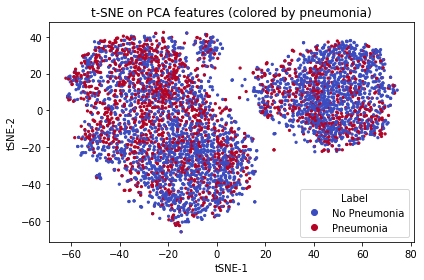

In [46]:
#tSNE w pneumonia labels shown
plt.figure()

scatter = plt.scatter(Z[:, 0], Z[:, 1], c=y_s, cmap="coolwarm", s=5)

plt.title("t-SNE on PCA features (colored by pneumonia)")
plt.xlabel("tSNE-1")
plt.ylabel("tSNE-2")

handles, _ = scatter.legend_elements()
plt.legend(handles, ["No Pneumonia", "Pneumonia"], title="Label")

plt.tight_layout()
plt.show()

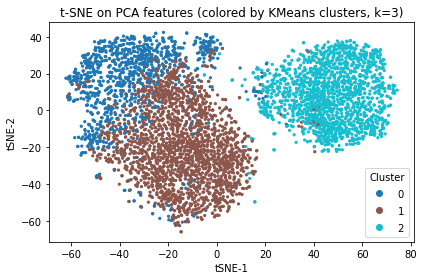

In [47]:
#tSNE w KMeans clusters shown
plt.figure()

scatter = plt.scatter(Z[:, 0], Z[:, 1], c=kmeans_s, cmap="tab10", s=5)

plt.title(f"t-SNE on PCA features (colored by KMeans clusters, k={best_k})")
plt.xlabel("tSNE-1")
plt.ylabel("tSNE-2")

# Generate legend automatically
handles, labels = scatter.legend_elements()
plt.legend(handles, labels, title="Cluster")

plt.tight_layout()
plt.show()

/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/site-packages/numpy/core/_asarray.py:171: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order, subok=True)


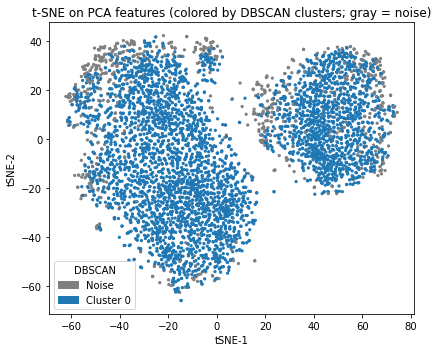

DBSCAN noise % in t-SNE subset: 0.1344


In [49]:
#tSNE with DBSCAN noise vs. non-noise
import matplotlib.patches as mpatches

plt.figure(figsize=(6,5))

colors = ["gray" if l == -1 else plt.cm.tab10(l % 10) for l in dbscan_s]

plt.scatter(Z[:, 0], Z[:, 1], c=colors, s=5)

plt.title("t-SNE on PCA features (colored by DBSCAN clusters; gray = noise)")
plt.xlabel("tSNE-1")
plt.ylabel("tSNE-2")

unique_labels = np.unique(dbscan_s)
legend_handles = []

for label in unique_labels:
    if label == -1:
        legend_handles.append(mpatches.Patch(color="gray", label="Noise"))
    else:
        legend_handles.append(mpatches.Patch(color=plt.cm.tab10(label % 10), label=f"Cluster {label}"))

plt.legend(handles=legend_handles, title="DBSCAN")

plt.tight_layout()
plt.show()

print("DBSCAN noise % in t-SNE subset:", (dbscan_s == -1).mean())

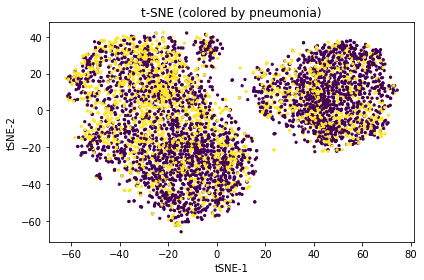

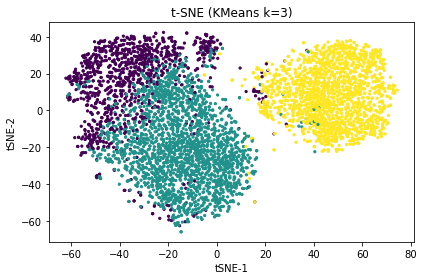

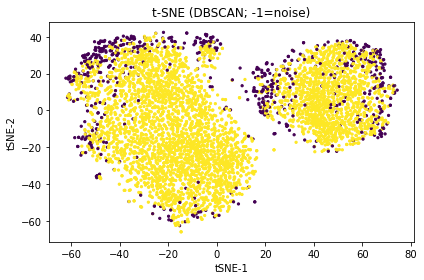

In [35]:
def save_scatter(Z, c, title, filename):
    plt.figure()
    plt.scatter(Z[:, 0], Z[:, 1], c=c, s=5)
    plt.title(title)
    plt.xlabel("tSNE-1")
    plt.ylabel("tSNE-2")
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=200)
    plt.show()

save_scatter(Z, y_s, "t-SNE (colored by pneumonia)", f"tsne_pneumonia_n{tsne_n}.png")
save_scatter(Z, kmeans_s, f"t-SNE (KMeans k={best_k})", f"tsne_kmeans_k{best_k}_n{tsne_n}.png")
save_scatter(Z, dbscan_plot, "t-SNE (DBSCAN; -1=noise)", f"tsne_dbscan_n{tsne_n}.png")

In [37]:
# Rough split by tSNE-1 coordinate
left = Z[:, 0] < np.median(Z[:, 0])
right = Z[:, 0] >= np.median(Z[:, 0])

print("Left pneumonia rate:", y_s[left].mean())
print("Right pneumonia rate:", y_s[right].mean())

Left pneumonia rate: 0.438
Right pneumonia rate: 0.328


In [38]:
# kmeans model already fit on PCA embeddings
centroids = km.cluster_centers_

# store results
cluster_examples = {}

for c in range(km.n_clusters):

    # indices belonging to cluster c
    cluster_idx = np.where(kmeans_labels == c)[0]

    # embeddings for cluster
    cluster_embeddings = X_pca[cluster_idx]

    # centroid for cluster
    centroid = centroids[c]

    # compute Euclidean distances
    dists = np.linalg.norm(cluster_embeddings - centroid, axis=1)

    # sort by distance
    closest = cluster_idx[np.argsort(dists)[:5]]

    cluster_examples[c] = closest

In [41]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

def show_and_save_cluster_images(cluster_id, n=5):

    idxs = cluster_examples[cluster_id][:n]

    fig, axes = plt.subplots(1, n, figsize=(3*n,3))

    for ax, idx in zip(axes, idxs):

        img_path = meta.iloc[idx]["image_path"]
        img = Image.open(img_path)

        ax.imshow(img, cmap="gray")
        ax.axis("off")

    plt.suptitle(f"Cluster {cluster_id}: Closest Images to Centroid")

    save_path = FIGURES_DIR / f"kmeans_cluster_{cluster_id}_examples.png"

    # save
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    # show
    plt.show()

    print(f"Saved: {save_path}")

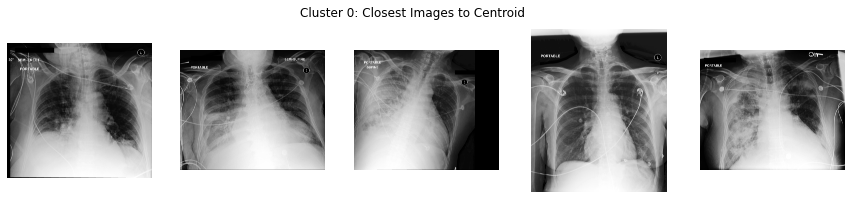

Saved: figures/kmeans_cluster_0_examples.png


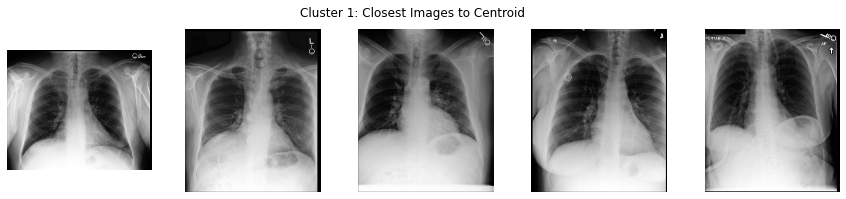

Saved: figures/kmeans_cluster_1_examples.png


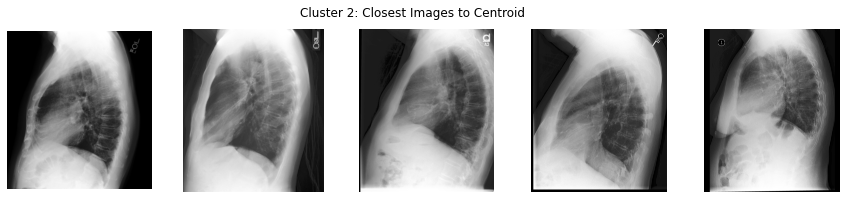

Saved: figures/kmeans_cluster_2_examples.png


In [42]:
for c in range(km.n_clusters):
    show_and_save_cluster_images(c)